# Compound identity and ADMET repair

Addresses R1.1 and R3.9; establishes the data used in every corrected experiment.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Trace the failed join

The original preparation discarded an invalid ADMET output, dropped a different row from the master table, reset both indices and concatenated columns by position. The resulting matrices had equal lengths but different identities. A raw string-SMILES mismatch alone is not used as the error count.

In [2]:
master = pd.read_csv(ROOT/'data/source/master_before_admet.csv.gz')
source = pd.read_csv(ROOT/'data/source/prepared_admet.csv.gz')
raw = pd.read_csv(ROOT/'data/source/admet_raw.csv.gz', usecols=['Cleaned SMILES','MW','hERG'], low_memory=False)
published = pd.read_csv(ROOT/'data/source/beyond_rmse/data/df_final.csv.gz')
invalid = raw[['MW','hERG']].eq('Invalid Molecule').any(axis=1)
assert len(master) == len(raw) == 12652
assert np.array_equal(raw.loc[~invalid, 'Cleaned SMILES'], source['Cleaned SMILES'])
actual_ids = master.loc[~invalid.to_numpy(), 'ligand_id'].to_numpy()
wrong = published.ligand_id.to_numpy() != actual_ids
display(pd.DataFrame({'published_ligand_id': published.ligand_id, 'source_ligand_id': actual_ids, 'wrong_association': wrong}).loc[wrong].head(8))
assert wrong.sum() == 1678
print('Invalid ADMET ID:', master.loc[invalid.to_numpy(),'ligand_id'].tolist())
print('Missing published master ID:', sorted(set(master.ligand_id)-set(published.ligand_id)))

,published_ligand_id,source_ligand_id,wrong_association
7437,9117,9116,True
7438,9118,9117,True
7439,9119,9118,True
7440,9120,9119,True
7441,9121,9120,True
7442,9122,9121,True
7443,9123,9122,True
7444,9124,9123,True


Invalid ADMET ID: [11434]
Missing published master ID: [9116]


## Restore the key, then require chemical confirmation

The original API request manifest is missing. Historical row correspondence is supported by the cleaning code, raw sequence and structural anchors, but is **not sufficient for acceptance**. We retain exact canonical isomeric matches or a unique identical uncharged isomeric parent in both sources. We do not erase stereochemistry or accept unresolved tautomer/redox transformations.

In [3]:
identity = pd.read_csv(PROCESSED/'identity_manifest.csv.gz')
allowed = identity[identity.identity_status.isin(['exact_isomeric_identity','unique_charge_parent'])]
admet_keyed = source.rename(columns={'Cleaned SMILES':'ADMET_source_SMILES'}).copy()
admet_keyed.insert(0, 'ligand_id', actual_ids)
assert admet_keyed.ligand_id.is_unique
rejoined = master[['ligand_id','Cleaned SMILES']].merge(admet_keyed, on='ligand_id', validate='one_to_one')
rejoined = rejoined[rejoined.ligand_id.isin(allowed.ligand_id)].set_index('ligand_id')
d = dataset()
assert set(rejoined.index) == set(d.index)
assert np.array_equal(rejoined.loc[d.index,'ADMET_source_SMILES'], d.ADMET_source_SMILES)
display(identity.identity_status.value_counts().rename('Compounds').to_frame())

,Compounds
identity_status,
exact_isomeric_identity,12193
unique_charge_parent,391
unresolved_structure_transform,67


In [4]:
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
uncharger = rdMolStandardize.Uncharger()
def chemical_key(s, neutral=False):
    mol = Chem.MolFromSmiles(s)
    assert mol is not None
    return Chem.MolToSmiles(uncharger.uncharge(mol) if neutral else mol, isomericSmiles=True)
for row in allowed.itertuples():
    neutral = row.identity_status == 'unique_charge_parent'
    assert chemical_key(row.master_smiles, neutral) == chemical_key(row.admet_smiles, neutral)
assert len(allowed) == 12584
print('Every retained pair passed its recorded structural-identity criterion.')

[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Running Uncharger
[19:36:39] Running Uncharger
[19:36:39] Removed negative charge.
[19:36:39] Runnin

[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19

[19:36:40] Running Uncharger
[19:36:40] Removed positive charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed positive charge.
[19:36:40] Removed positive charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed positive charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Runnin

[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed positive charge.
[19:36:40] Removed positive charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Unchar

[19:36:40] Running Uncharger
[19:36:40] Removed positive charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:40] Running Uncharger
[19:36:40] Removed negative charge.
[19:36:40] Removed negative charge.
[19:36:40] Running Uncharger
[19:36:41] Running Uncharger
[19:36:41] Removed positive charge.
[19:36:41] Removed positive charge.
[19:36:41] Running Uncharger
[19:36:41] Running Uncharger
[19:36:41] Removed positive charge.
[19:36:41] Removed positive charge.
[19:36:41] Running Uncharger
[19:36:41] Running Uncharger
[19:36:41] Removed positive charge.
[19:36:41] Removed positive charge.
[19:36:41] Running Uncharger
[19:36:41] Running Uncharger
[19:36:41] Removed positive charge.
[19:36:41] Running Uncharger
[19:36:41] Running Uncharger
[19:36:41] Removed negative charge.
[19:36:41] Running Uncharger
[19:36:41] Running Uncharger
[19:36:41] Removed negative charge.
[19:36:41] Running Uncharger
[19:36:41]

...

[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19

[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[1

[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed positive charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42] Running Uncharger
[19:36:42] Removed negative charge.
[19:36:42] Running Uncharger
[19:36:42]

Every retained pair passed its recorded structural-identity criterion.


[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed negative charge.
[19:36:43] Running Uncharger
[19:36:43] Running Uncharger
[19:36:43] Removed positive cha

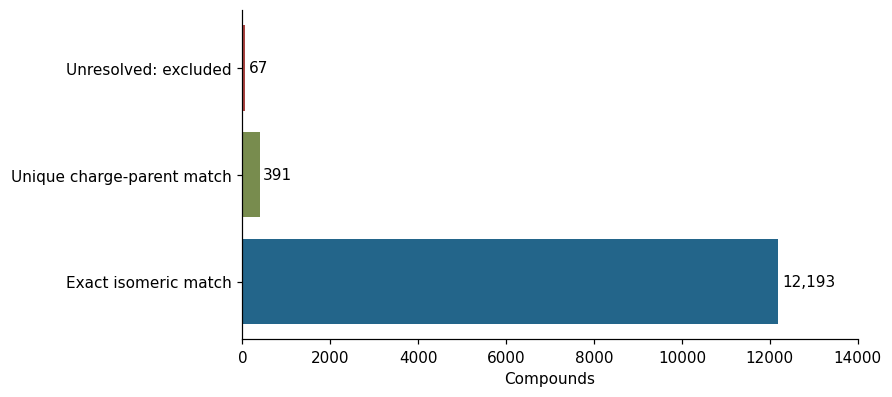

In [5]:
counts = identity.identity_status.value_counts()
fig, ax = plt.subplots(figsize=(8,3.5), layout='constrained')
labels = ['Exact isomeric match','Unique charge-parent match','Unresolved: excluded']
vals = [counts['exact_isomeric_identity'],counts['unique_charge_parent'],counts['unresolved_structure_transform']]
ax.barh(labels, vals, color=['#23658a','#788c4e','#a94340'])
for i,v in enumerate(vals): ax.text(v+80,i,f'{v:,}',va='center')
ax.set(xlabel='Compounds',xlim=(0,14000));finish(fig,'identity_accounting')

## Inclusion and label checks

The valid omitted ID 9116 is restored. The invalid ADMET ID 11434 and 67 unresolved transformations are excluded without using toxicity outcomes or residuals. ID 1298, removed from the historical confidence test, is retained. Original and candidate-full tables are provenance only.

In [6]:
assert 9116 in d.index and 1298 in d.index and 11434 not in d.index
assert len(dataset(strict=True)) == 12193
expected = -d['lgLD50, mg/kg'] + 3 + np.log10(d['MW, g/mol'])
assert np.allclose(d[TARGET],expected,atol=1e-12)
print('Primary:',len(d),'Strict:',len(dataset(True)))

Primary: 12584 Strict: 12193
